In [ ]:
!pip install zarr
import os
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
import zarr

# Replace this with an actual folder name from your downloaded dataset
sample_zarr_path = '/content/drive/MyDrive/BioHUB/dataset/train/6bba_0e7c0d07.zarr'

# Open the zarr directory (read-only mode)
image_volume = zarr.open(sample_zarr_path, mode='r')

# The description says the actual image data is inside a folder named '0'
video_data = image_volume['0']

print("Data shape (Time, Z, Y, X):", video_data.shape)
print("Data type:", video_data.dtype)

# To load just the FIRST timepoint into RAM as a NumPy array:
first_frame_3d = video_data[0, :, :, :]

Data shape (Time, Z, Y, X): (100, 64, 256, 256)
Data type: uint16


In [ ]:
first_frame_3d.shape

(64, 256, 256)

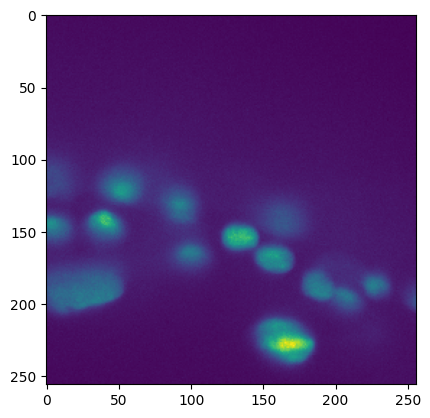

In [ ]:
plt.imshow(first_frame_3d[0,:,:])

In [ ]:
sample_geff_path = '/content/drive/MyDrive/BioHUB/dataset/train/6bba_0e7c0d07.geff'
graph_data = zarr.open(sample_geff_path, mode='r')

# Load Node IDs
node_ids = graph_data['nodes/ids'][:]

# Load Coordinates for those nodes (Time, Z, Y, X)
t_coords = graph_data['nodes/props/t/values'][:]
z_coords = graph_data['nodes/props/z/values'][:]
y_coords = graph_data['nodes/props/y/values'][:]
x_coords = graph_data['nodes/props/x/values'][:]

# Load Edges (How cells connect frame-to-frame)
edges = graph_data['edges/ids'][:]

print(f"Loaded {len(node_ids)} cell detections and {len(edges)} temporal links.")

Loaded 209 cell detections and 198 temporal links.


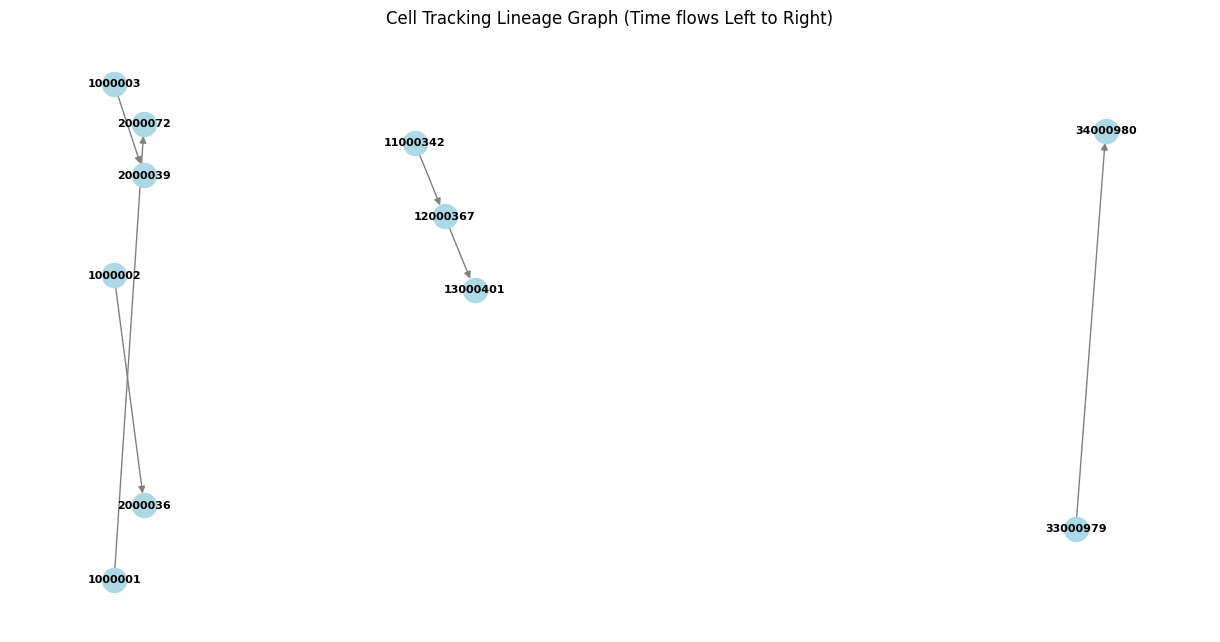

In [ ]:

# Assuming 'edges_array' is your actual loaded numpy array from the .geff file
# For this example, I am using the exact snippet you provided
edges_array = np.array([
    [ 1000001,  2000072],
    [ 1000002,  2000036],
    [ 1000003,  2000039],
    [11000342, 12000367],
    [12000367, 13000401],
    [33000979, 34000980]
], dtype=np.uint64)

# 1. Create the directed graph
G = nx.DiGraph()
G.add_edges_from(edges_array)

# 2. Extract the 'Timepoint' from the Node ID to use as the X-coordinate
# We divide by 1,000,000 to get the prefix (e.g., 12000367 // 1000000 = 12)
pos = {}
for node in G.nodes():
    time_frame = node // 1000000

    # Assign X to time_frame, and random Y to spread them out vertically
    pos[node] = (time_frame, np.random.rand())

# 3. Plot the graph
plt.figure(figsize=(12, 6))
nx.draw(G, pos,
        node_size=300,
        node_color='lightblue',
        edge_color='gray',
        with_labels=True,
        font_size=8,
        font_weight='bold',
        arrows=True)

plt.title("Cell Tracking Lineage Graph (Time flows Left to Right)")
plt.xlabel("Timepoint (Extracted from ID prefix)")
plt.show()

In [ ]:
edges

array([[ 1000001,  2000072],
       [ 1000002,  2000036],
       [ 1000003,  2000039],
       ...,
       [12000367, 13000401],
       [11000342, 12000367],
       [33000979, 34000980]], dtype=uint64)

Min Intensity: 2
Max Intensity: 1095
Mean Intensity: 49.33


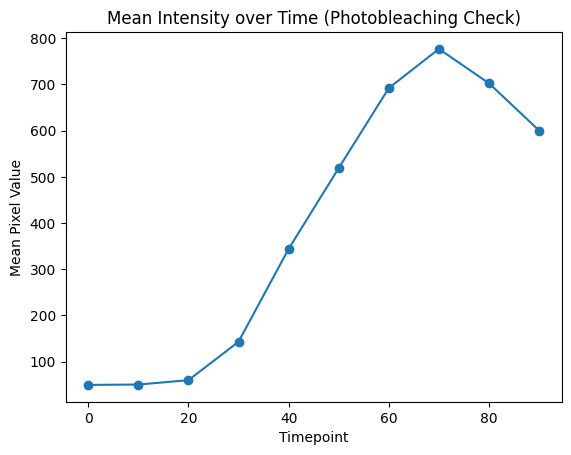

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Quick check on a single timepoint (e.g., t=0)
frame_data = video_data[0, :, :, :]

print(f"Min Intensity: {frame_data.min()}")
print(f"Max Intensity: {frame_data.max()}")
print(f"Mean Intensity: {frame_data.mean():.2f}")

# Plotting intensity over time to check for photobleaching
means_over_time = [video_data[t, :, :, :].mean() for t in range(0, video_data.shape[0], 10)]
plt.plot(range(0, video_data.shape[0], 10), means_over_time, marker='o')
plt.title("Mean Intensity over Time (Photobleaching Check)")
plt.xlabel("Timepoint")
plt.ylabel("Mean Pixel Value")
plt.show()

In [ ]:
import numpy as np

# Let's say we are looking at the first 3D frame
frame = video_data[0, :, :, :]

# Rough estimate: The top 1% of brightest pixels are "cells"
threshold = np.percentile(frame, 99)

# Separate the image into signal (cells) and background
signal_pixels = frame[frame > threshold]
background_pixels = frame[frame <= threshold]

# Calculate the components
mu_signal = signal_pixels.mean()
mu_background = background_pixels.mean()
sigma_background = background_pixels.std()

# Calculate SNR
snr = (mu_signal - mu_background) / sigma_background

print(f"Mean Signal: {mu_signal:.2f}")
print(f"Mean Background: {mu_background:.2f}")
print(f"Background Noise (Std Dev): {sigma_background:.2f}")
print(f"Estimated SNR: {snr:.2f}")

Mean Signal: 491.21
Mean Background: 44.88
Background Noise (Std Dev): 41.33
Estimated SNR: 10.80


## GNN model testing

In [ ]:
!pip install torch torchvision torchaudio
!pip install torch_geometric

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import KarateClub
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv

# ==========================================
# 1. Load Data & Prepare Link Prediction
# ==========================================
# The Karate Club dataset is a small social network of 34 members.
dataset = KarateClub()
data = dataset[0]

# For link prediction, we need to hide some edges to test if our model can predict them.
# We also need "negative edges" (pairs of people who aren't friends) to teach the model
# what a non-link looks like. RandomLinkSplit handles all of this automatically!
transform = RandomLinkSplit(
    num_val=0.1,       # 10% of edges for validation
    num_test=0.1,      # 10% of edges for testing
    is_undirected=True # Social network friendships are mutual
)
train_data, val_data, test_data = transform(data)

# ==========================================
# 2. Define the GNN Model
# ==========================================
class SocialLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Two Graph Convolutional Layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, x, edge_index):
        # The ENCODER: Learns user embeddings based on their network neighborhood
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

    def decode(self, z, edge_label_index):
        # The DECODER: Takes two user embeddings and takes the dot product
        # A higher dot product means a higher chance they are/should be friends
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)

# Initialize the model, optimizer, and loss function
model = SocialLinkPredictor(dataset.num_features, 16, 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss() # Binary Cross Entropy for Yes/No link prediction

# ==========================================
# 3. Training Loop
# ==========================================
def train():
    model.train()
    optimizer.zero_grad()

    # 1. Encode the graph (pass the known training edges to get embeddings)
    z = model.encode(train_data.x, train_data.edge_index)

    # 2. Decode the probabilities (guess friendships for the training edge labels)
    # Note: edge_label_index contains both real friendships (1s) and fake friendships (0s)
    out = model.decode(z, train_data.edge_label_index)
    print(len(out))
    print()
    print(train_data.edge_label)
    return

    # 3. Calculate loss and update weights
    loss = criterion(out, train_data.edge_label)
    loss.backward()
    optimizer.step()

    return loss.item()

print("Starting training...")
for epoch in range(1, 101):
    loss = train()
    break
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")